In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import confusion_matrix, classification_report 

In [3]:
df = pd.read_csv('dulieuxettuyendaihoc.csv', header=0)
df

,MSSV,T1,T2,T3,T4,T5,T6,GT,DT,KV,NGONNGU,TOANLOGICPHANTICH,GIAIQUYETVANDE,KT,NGAYTHI,DINHHUONGNGHENGHIEP
0,SV001,7.2,8.4,7.4,7.2,7.4,6.9,F,NaN,2NT,3.25,3.25,4.50,A1,12/7/2018,No
1,SV002,5.4,6.3,4.3,4.9,3.0,4.0,M,NaN,1,6.00,4.00,3.50,C,12/7/2018,Yes
2,SV003,5.6,5.0,2.8,6.1,4.8,5.7,M,NaN,1,5.00,6.75,4.00,C,12/7/2018,No
3,SV004,6.6,5.1,5.9,4.1,6.1,7.4,M,NaN,1,4.25,4.25,5.25,D1,12/7/2018,No
4,SV005,6.0,5.4,7.6,4.4,6.8,8.0,M,NaN,2NT,4.25,4.50,5.00,A,12/7/2018,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,SV0096,8.6,8.9,7.7,6.7,7.9,6.6,F,NaN,1,5.25,1.50,6.25,C,7/20/2022,Yes
96,SV0097,3.7,4.1,3.1,3.4,5.5,5.7,F,NaN,1,5.25,3.75,4.75,C,7/20/2022,No
97,SV0098,8.8,9.5,9.5,8.5,9.0,8.5,M,NaN,2NT,7.00,8.00,4.00,C,7/20/2022,Yes
98,SV0099,2.7,2.8,6.2,5.2,4.1,4.3,M,NaN,1,5.00,3.50,5.50,C,7/20/2022,No


In [5]:
df = df[['NGONNGU','TOANLOGICPHANTICH','GIAIQUYETVANDE','DINHHUONGNGHENGHIEP']]

In [7]:
# rename columns TOANLOGICPHANTICH thanh logic, GIAIQUYETVANDE thanh ungxu
df.rename(columns={'TOANLOGICPHANTICH':'LOGIC', 'GIAIQUYETVANDE':'UNGXU','DINHHUONGNGHENGHIEP':'DINHHUONG'}, inplace=True)
df.head()

C:\Users\Admin\AppData\Local\Temp\ipykernel_10100\3613475369.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename(columns={'TOANLOGICPHANTICH':'LOGIC', 'GIAIQUYETVANDE':'UNGXU','DINHHUONGNGHENGHIEP':'DINHHUONG'}, inplace=True)


,NGONNGU,LOGIC,UNGXU,DINHHUONG
0,3.25,3.25,4.50,No
1,6.00,4.00,3.50,Yes
2,5.00,6.75,4.00,No
3,4.25,4.25,5.25,No
4,4.25,4.50,5.00,No


In [ ]:
# Dua vao cac diem thi danh gia nang luc, phan doan xem sinh vien co dinh huong nghe nghiep hay chua duoc dinh huong nghe nghiep
# Input Logic, ngonngu, ungxu
# Output: Dinhhuong
# Dinhhuong = f(logic,ngonngu,ungxu)
'''
Ý TƯỞNG tính Z = A0 + A1 +LOGIC + A2+ NN + UX + E
TỪ ĐÓ TÍNH f(x) = 1/(1+e^(-Z)) thuộc [0,1]
NẾu mà f(x) > 0.5 thì sinh viên đó đã được định hướng nghề nghiệp
NẾu mà f(x) < 0.5 thì sinh viên đó chưa được định hướng nghề nghiệp
'''

In [8]:
dinhhuong = pd.get_dummies(df['DINHHUONG'],drop_first=True)
df.drop(['DINHHUONG'],axis=1,inplace=True)
df = pd.concat([df,dinhhuong],axis=1)
df.head(5)

C:\Users\Admin\AppData\Local\Temp\ipykernel_10100\3757327056.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(['DINHHUONG'],axis=1,inplace=True)


,NGONNGU,LOGIC,UNGXU,Yes
0,3.25,3.25,4.50,False
1,6.00,4.00,3.50,True
2,5.00,6.75,4.00,False
3,4.25,4.25,5.25,False
4,4.25,4.50,5.00,False


In [9]:
x = df[['NGONNGU','LOGIC','UNGXU']].values
y = df['Yes'].values


In [10]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=1)

In [11]:
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression()
classifier.fit(X_train, y_train)

LogisticRegression()

In [12]:
classifier.coef_
# A1(NGONNGU): 0.27992467
# A2(LOGIC):0.05627405
# A3(UNGXU):-0.0966801

array([[ 0.27992467,  0.05627405, -0.0966801 ]])

In [13]:
classifier.intercept_
# A0 = -1.15699883

array([-1.15699883])

In [ ]:
'''
Phương trình phân lớp
p(x) = 1/(1+e^(-Z))
Yes = threshold(p(x),0.5)
'''

In [14]:
# Với điểm ngôn ngữ là 7.5 , logic là 6.5 và ứng xử là 7.0 thì sinh viên có định hướng hay không
# Đáp án :Yes : ? 
# Z = 0.631 ( đoạn này thay só trên phương trình)
Z = classifier.intercept_ + classifier.coef_[0][0]*7.5 + classifier.coef_[0][1]*6.5 + classifier.coef_[0][2]*7.0
print(Z)

[0.63145673]


In [15]:
p = 1/(1+np.exp(-Z))
print(p)

if p > 0.5:
    print('Yes')
else:
    print('No')

[0.6528197]
Yes


In [16]:
# Với điểm ngôn ngữ là 7.5 , logic là 6.5 và ứng xử là 5.0 thì sinh viên có định hướng hay không
# Đáp án :Yes : ? 
# Z = 0.8248 ( đoạn này thay só trên phương trình)
Z = classifier.intercept_ + classifier.coef_[0][0]*7.5 + classifier.coef_[0][1]*6.5 + classifier.coef_[0][2]*5.0
print(Z)

[0.82481694]


In [17]:
p = 1/(1+np.exp(-Z))
print(p)

if p > 0.5:
    print('Yes')
else:
    print('No')

[0.69525789]
Yes


In [18]:
def classifier_cal(a,b,c):
    Z = classifier.intercept_ + classifier.coef_[0][0]*a + classifier.coef_[0][1]*b + classifier.coef_[0][2]*c
    return 1/(1+np.exp(-Z))
p = classifier_cal(7.6,6.5,5.0)
print(p)

if p > 0.5:
    print('Yes')
else:
    print('No')
    


[0.70115615]
Yes


In [19]:
# Defauly threshold = 0.5
y_pred = classifier.predict(X_test)
y_pred

array([False,  True, False, False, False, False, False, False, False,
       False, False, False,  True, False, False, False, False, False,
       False, False,  True, False,  True, False, False, False, False,
        True, False, False])

In [20]:
'''
hanging threshold and predicting
print(classifier.predict_proba(X_test))'''

print('Prediction with threshold 0.9:  ')
y_pred_new_threshold = (classifier.predict_proba(X_test)[:,1] >= 0.9).astype(int)
print(y_pred_new_threshold)

Prediction with threshold 0.9:  
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [21]:
result = pd.DataFrame({'Actual':y_test.flatten().astype(int),
                        'Predicted':y_pred.astype(int)})
result.head(5)

,Actual,Predicted
0,1,0
1,1,1
2,1,0
3,0,0
4,1,0


In [22]:
from sklearn.metrics import confusion_matrix
cf_matrix = confusion_matrix(y_test, y_pred)
cf_matrix

array([[12,  2],
       [13,  3]], dtype=int64)

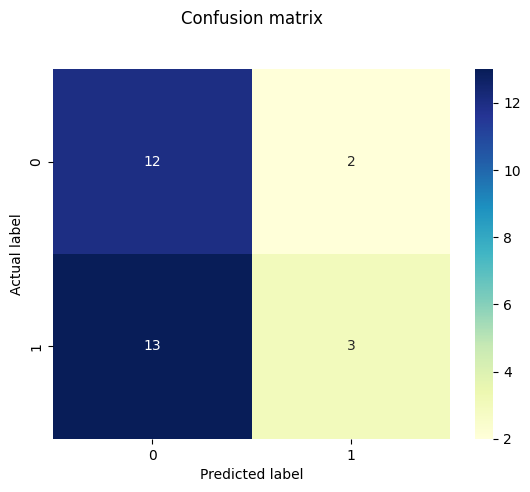

In [23]:
sns.heatmap(pd.DataFrame(cf_matrix), annot=True, cmap='YlGnBu', fmt='g')
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.show()

In [24]:
from sklearn.metrics import accuracy_score  
print('Accuracy Score :',accuracy_score(y_test, y_pred))

Accuracy Score : 0.5


In [25]:
target_names = ['Not oriented', 'Oriented']
print(classification_report(y_test, y_pred, target_names=target_names))


              precision    recall  f1-score   support

Not oriented       0.48      0.86      0.62        14
    Oriented       0.60      0.19      0.29        16

    accuracy                           0.50        30
   macro avg       0.54      0.52      0.45        30
weighted avg       0.54      0.50      0.44        30

